# Homework 5

In [1]:
import arviz as az
import pymc as pm
from pymc.math import switch, ge, le, gt
import pandas as pd
import numpy as np

rng = np.random.default_rng(6420)

d:\anaconda3\envs\pymc_env\Lib\site-packages\arviz\__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


## Question 1

In [2]:
data = pd.read_csv("data/hadlock.csv").iloc[:, :2]
data.columns = ["MA", "BPD"]
data.head()

,MA,BPD
0,12,2.19
1,13,2.20
2,13,2.31
3,13,2.29
4,14,2.58


Model:
$$
BPD = \beta_0 + \beta_1\sqrt{MA} + \epsilon
$$
where $\epsilon \sim N(0, \sigma^2)$


In [3]:
ma_values = data["MA"].to_numpy()
bpd_values = data["BPD"].to_numpy()

with pm.Model() as m:
    ma_shared = pm.Data("ma", ma_values)
    
    beta_0 = pm.Normal("beta_0", mu=0, sigma=5)
    beta_1 = pm.Normal("beta_1", mu=0, sigma=5)
    
    sigma = pm.Exponential("sigma", lam=2)

    # Hypothesis test for beta_1 > 8/3
    h1 = pm.Deterministic("h1", switch(gt(beta_1, 8/3), 1, 0))
    h0 = pm.Deterministic("h0", switch(le(beta_1, 8/3), 0, 1))

    mu = beta_0 + beta_1 * pm.math.sqrt(ma_shared)
    # Likelihood
    pm.Normal(
        "bpd_obs", mu=mu, sigma=sigma, observed=bpd_values
        )

    # Make an out of-sample prediction for MA = 10.5
    ma_new = 10.5
    oos_mean = pm.Deterministic("mean|ma=10.5", beta_0 + beta_1 * pm.math.sqrt(ma_new))
    pm.Normal("oos_pred", mu=oos_mean, sigma=sigma)

    # Sampling
    trace = pm.sample(2000, random_seed=6420, target_accept=0.95)
    ppc = pm.sample_posterior_predictive(trace, random_seed=6420)

d:\anaconda3\envs\pymc_env\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta_0, beta_1, sigma, oos_pred]


d:\anaconda3\envs\pymc_env\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for Jupyter 
support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 33 seconds.
Sampling: [bpd_obs]


d:\anaconda3\envs\pymc_env\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for Jupyter 
support
  warnings.warn('install "ipywidgets" for Jupyter support')

In [4]:
az.summary(trace)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_0,-7.454,0.068,-7.579,-7.322,0.001,0.001,2928.0,3746.0,1.0
beta_1,2.700,0.013,2.673,2.723,0.000,0.000,2944.0,3834.0,1.0
oos_pred,1.300,0.240,0.823,1.735,0.003,0.003,4908.0,4707.0,1.0
sigma,0.243,0.008,0.229,0.257,0.000,0.000,4642.0,3989.0,1.0
h1,0.992,0.088,1.000,1.000,0.001,0.008,4189.0,8000.0,1.0
h0,0.992,0.088,1.000,1.000,0.001,0.008,4189.0,8000.0,1.0
mean|ma=10.5,1.294,0.027,1.246,1.346,0.000,0.000,3099.0,4154.0,1.0


array([<Axes: title={'center': '94.0% HDI'}>], dtype=object)

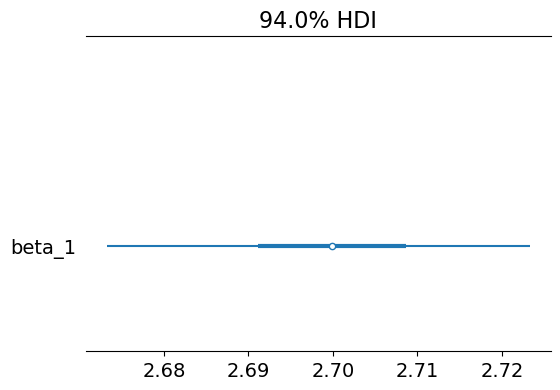

In [5]:
az.plot_forest(trace, var_names=["beta_1"], combined=True)

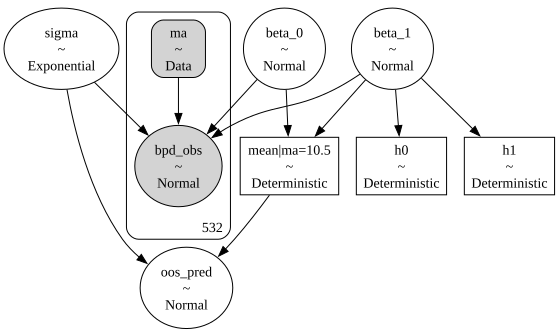

In [6]:
pm.model_to_graphviz(m)

<Axes: title={'center': 'beta_1'}>

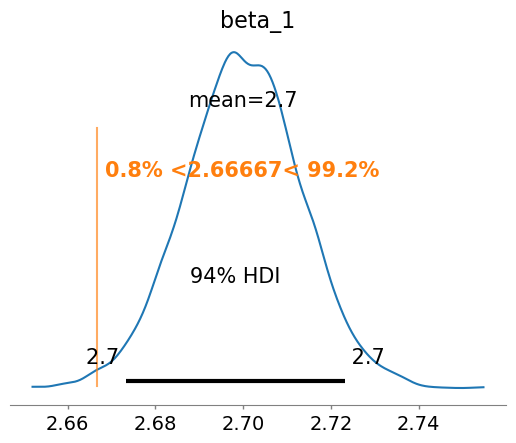

In [7]:
az.plot_posterior(trace, var_names=["beta_1"], ref_val=8/3)

In [8]:
y_pred = ppc.posterior_predictive.stack(sample=("chain", "draw"))[
    "bpd_obs"
].values.T
y_pred
az.r2_score(bpd_values, y_pred)

r2        0.973745
r2_std    0.001598
dtype: float64

## Question 2

In [9]:
nano_data = pd.read_csv("data/nanowire.csv")
nano_data.head()

,x,y
0,0.0,123
1,0.0,123
2,2.5,46
3,2.5,48
4,5.0,8


In [10]:
# Density of wires follows Poission distribution
upper_bound = 100
with pm.Model() as m2:
    x_data = pm.Data("x", nano_data["x"].to_numpy())
    # Theta parameters
    theta_1 = pm.Uniform("theta_1", lower=0, upper=upper_bound)
    theta_2 = pm.Uniform("theta_2", lower=0, upper=1)
    theta_3 = pm.Uniform("theta_3", lower=0, upper=upper_bound)
    theta_4 = pm.Uniform("theta_4", lower=0, upper=upper_bound)
    # Priors
    std_normal = pm.Normal.dist(mu=0, sigma=1)
    log_cdf = pm.logcdf(rv=std_normal, value=(-x_data/theta_4))
    Phi_term = np.exp(log_cdf)

    mu = theta_1*np.exp(-theta_2*x_data**2) + theta_3*(1-np.exp(-theta_2*x_data**2))*Phi_term
    # Likelihood
    pm.Poisson("y_obs", mu=mu, observed=nano_data["y"].to_numpy())
    # Sampling
    trace2 = pm.sample(2000, random_seed=6420, target_accept=0.95)
az.summary(trace2, hdi_prob=0.95)     

d:\anaconda3\envs\pymc_env\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [theta_1, theta_2, theta_3, theta_4]


d:\anaconda3\envs\pymc_env\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for Jupyter 
support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 28 seconds.


,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
theta_1,98.231,1.645,94.882,100.000,0.021,0.023,3494.0,2322.0,1.0
theta_2,0.151,0.023,0.110,0.198,0.000,0.000,3124.0,4096.0,1.0
theta_3,26.796,8.170,12.394,43.820,0.150,0.129,2770.0,2297.0,1.0
theta_4,11.967,4.100,7.443,17.755,0.128,0.634,2800.0,2230.0,1.0


In [16]:
# predictive distrubution when density is 2
x_new = 2
with m2:
    pm.set_data({"x": [x_new]})
    ppc2 = pm.sample_posterior_predictive(trace2, random_seed=6420, predictions=True)

# Get summary of the predictive distribution
az.summary(ppc2.predictions, hdi_prob=0.95)

Sampling: [y_obs]


d:\anaconda3\envs\pymc_env\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for Jupyter 
support
  warnings.warn('install "ipywidgets" for Jupyter support')

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
y_obs[0],58.986,8.501,42.0,75.0,0.099,0.070,7402.0,7171.0,1.0
y_obs[1],59.044,8.465,42.0,75.0,0.100,0.071,7197.0,6889.0,1.0
y_obs[2],59.024,8.473,41.0,74.0,0.106,0.071,6397.0,7208.0,1.0
y_obs[3],58.983,8.449,41.0,74.0,0.098,0.073,7456.0,7540.0,1.0
y_obs[4],59.212,8.561,42.0,75.0,0.101,0.071,7130.0,7761.0,1.0
y_obs[5],59.001,8.483,43.0,75.0,0.101,0.069,7041.0,7166.0,1.0
y_obs[6],59.024,8.533,41.0,74.0,0.100,0.071,7193.0,7351.0,1.0
y_obs[7],59.070,8.585,42.0,75.0,0.105,0.070,6688.0,7630.0,1.0
y_obs[8],59.044,8.537,42.0,75.0,0.100,0.072,7333.0,7388.0,1.0
y_obs[9],59.034,8.446,41.0,74.0,0.104,0.069,6609.0,7401.0,1.0
